<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/simple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/height_weight_50_records.csv')
df.head(10)

,Height_cm,Weight_kg
0,188,100.1
1,178,88.3
2,164,74.5
3,192,102.3
4,157,69.7
5,170,83.0
6,188,98.5
7,168,82.4
8,172,81.0
9,160,77.3


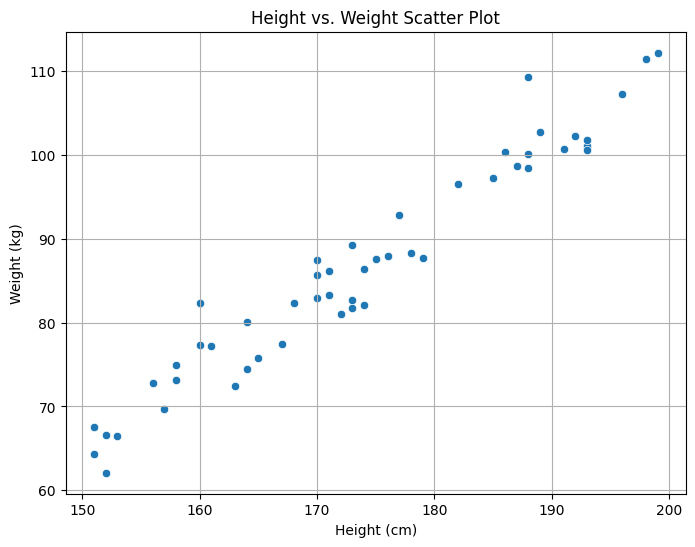

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Height_cm', y='Weight_kg', data=df)
plt.title('Height vs. Weight Scatter Plot')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.grid(True)
plt.show()

In [ ]:
x = df['Height_cm']
y = df['Weight_kg']

print("Head of x (Height_cm):")
display(x.head())

print("\nHead of y (Weight_kg):")
display(y.head())

Head of x (Height_cm):


,Height_cm
0,188
1,178
2,164
3,192
4,157



Head of y (Weight_kg):


,Weight_kg
0,100.1
1,88.3
2,74.5
3,102.3
4,69.7


# Task
Split the `x` (Height_cm) and `y` (Weight_kg) data into training and testing sets, standardize the features using `StandardScaler`, train a `LinearRegression` model, use the trained model to predict `y_pred` on `x_test` and extract the intercept and slope, and finally, re-perform the Ordinary Least Squares (OLS) method using `statsmodels` for the entire dataset "/content/height_weight_50_records.csv".

## Split Data

### Subtask:
Split the `x` (Height_cm) and `y` (Weight_kg) data into training and testing sets (`x_train`, `x_test`, `y_train`, `y_test`) using a random split method.


**Reasoning**:
To split the data into training and testing sets, I need to import the `train_test_split` function from `sklearn.model_selection`.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (40,)
Shape of x_test: (10,)
Shape of y_train: (40,)
Shape of y_test: (10,)


## Standardize Features

### Subtask:
Standardize the `x_train` and `x_test` data using `StandardScaler` to ensure features are on a similar scale.


**Reasoning**:
To standardize the features, I need to import StandardScaler, instantiate it, reshape the data, fit the scaler on the training data, and then transform both training and testing data.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Reshape x_train and x_test to 2D arrays
x_train_reshaped = x_train.values.reshape(-1, 1)
x_test_reshaped = x_test.values.reshape(-1, 1)

# Fit the scaler on x_train and transform both x_train and x_test
x_train_scaled = scaler.fit_transform(x_train_reshaped)
x_test_scaled = scaler.transform(x_test_reshaped)

print("Shape of x_train_scaled:", x_train_scaled.shape)
print("Shape of x_test_scaled:", x_test_scaled.shape)
print("First 5 elements of x_train_scaled:\n", x_train_scaled[:5])
print("First 5 elements of x_test_scaled:\n", x_test_scaled[:5])

Shape of x_train_scaled: (40, 1)
Shape of x_test_scaled: (10, 1)
First 5 elements of x_train_scaled:
 [[ 0.76710031]
 [-1.26880572]
 [-1.63236037]
 [-0.17814178]
 [ 1.27607681]]
First 5 elements of x_test_scaled:
 [[ 1.05794403]
 [-1.34151665]
 [ 0.11270194]
 [-0.03271992]
 [-1.7050713 ]]


## Train Linear Regression Model

### Subtask:
Train a `LinearRegression` model using the standardized training data.


**Reasoning**:
To train a Linear Regression model, I need to import the `LinearRegression` class, instantiate it, and then fit the model using the scaled training features and the training target variable.



In [ ]:
from sklearn.linear_model import LinearRegression

# Instantiate LinearRegression model
model = LinearRegression()

# Fit the model to the scaled training data
model.fit(x_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Predict and Extract Parameters

### Subtask:
Use the trained model to predict `y_pred` on `x_test`, and extract the intercept and slope coefficients from the model.


**Reasoning**:
To complete the subtask, I need to use the trained LinearRegression model to make predictions on the scaled test data and then extract the intercept and slope coefficients from the model.



In [ ]:
y_pred = model.predict(x_test_scaled)

intercept = model.intercept_
slope = model.coef_[0] # .coef_ returns an array even for a single feature

print("Predicted y_pred (first 5 values):\n", y_pred[:5])
print("\nModel Intercept:", intercept)
print("Model Slope:", slope)

Predicted y_pred (first 5 values):
 [100.76246778  69.99089137  88.64033162  86.77538759  65.3285313 ]

Model Intercept: 87.195
Model Slope: 12.82437203535843


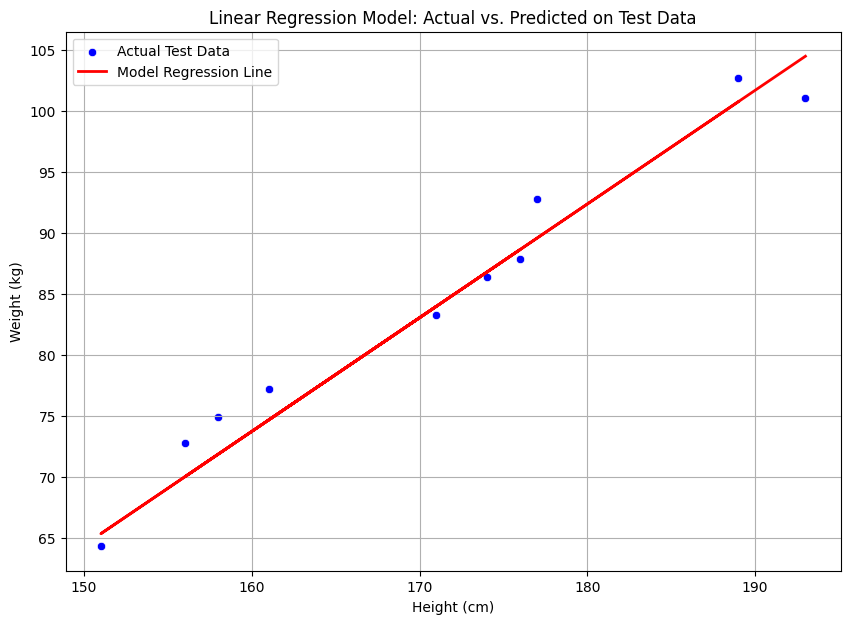

In [ ]:
x_test_original_scale = scaler.inverse_transform(x_test_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=x_test, y=y_test, color='blue', label='Actual Test Data')
plt.plot(x_test_original_scale, y_pred, color='red', linestyle='-', linewidth=2, label='Model Regression Line')
plt.title('Linear Regression Model: Actual vs. Predicted on Test Data')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

# Get height input from the user
height_input_cm = float(input("Enter a height value in cm to predict weight: "))

# Reshape the input to be a 2D array, as expected by the scaler
height_input_reshaped = np.array([[height_input_cm]])

# Standardize the input height using the fitted scaler
height_input_scaled = scaler.transform(height_input_reshaped)

# Predict the weight using the trained model
predicted_weight_kg = model.predict(height_input_scaled)[0]

print(f"For a height of {height_input_cm} cm, the predicted weight is {predicted_weight_kg:.2f} kg.")

Enter a height value in cm to predict weight: 170
For a height of 170.0 cm, the predicted weight is 83.05 kg.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Squared Error (MSE): 5.15
Mean Absolute Error (MAE): 1.98
